# Ⅰ第1回 GW3 試行③　シンプルな CNN × オリジナル画像

データは試行②と同じオリジナル画像のまま，**モデルだけを CNN に替える**．

1. 試行②（`ex0_2_mlp_original.ipynb`）と同じ番号に，同じカードを貼る
2. ただし **モデルを定義するセル 1 つ** には，差し替えカード R を貼る
3. 上から実行し，最後の「記録」のセルまで実行する．試行②と正解率を比べる
4. 最後の課題（MLP と CNN の説明）を書く


## (0) グループと役割の設定

In [1]:
# ===== (0) グループと役割の設定 =====
GROUP_ID = 16                  # ← 自分のグループ番号 (1〜27) に書き換える
MEMBER_ROLE = "recorder"   # implementer / verifier / recorder / presenter（5 人グループは collector も）のいずれか．3 人グループで presenter を兼ねる verifier は "verifier"

# 授業用フォルダ（AI_TD）のルートを import パスに追加する（ノートブックをどこから開いても動く）
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / ".dlcourse_root").exists())
sys.path.insert(0, str(ROOT))
print("作業フォルダ:", ROOT)

作業フォルダ: /Users/yamato/AI_TD


## コードを貼るセル（①〜⑪）

見出しに GW2-1 のカード名を写してから，合うコードを下の空のセルに貼る．

## データ準備フェーズ（①〜④）

### コードテンプレート①

カード名：O　カード：ライブラリのインポート

In [2]:
# PyTorch 本体と，ニューラルネットワーク・最適化・画像処理の部品を読み込む
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from torch.utils.data import Dataset
# グラフを描く道具
import matplotlib.pyplot as plt
import seaborn as sns
# 処理の進み具合をバーで表示する道具
from tqdm import tqdm
import random
import numpy as np

# 追加
# フォルダごとに分けた画像を読み込む道具（フォルダ名がクラスになる）
from torchvision.datasets import ImageFolder

### コードテンプレート②

カード名：Q　カード：データの前処理

In [3]:
# 前処理：訓練用・検証用とも 64×64 に縮小してからテンソルに変換する
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
    ]),
    'val': transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
    ])
}

### コードテンプレート③

カード名：P　カード：データセットの準備

In [4]:
IMAGE_DIR = str(ROOT / 'assets' / 'cable1')   # オリジナル画像（2 クラス × 100 枚）

# class0／class1 フォルダの画像を読み込む（ラベルはフォルダで決まる）
full_dataset = ImageFolder(root=IMAGE_DIR)

# 乱数の種を固定して，同じ条件の結果を再現しやすくする（機種や版が違うと一致しないこともある）
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(0)

# 全 200 枚を 70% 訓練用・15% 検証用・15% テスト用に分ける（テスト用は学習にも調整にも使わない）
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_subset, val_subset, test_subset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

# 分けたデータに，訓練用・検証用それぞれの前処理をかけるための入れ物
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        image, label = self.subset[index]
        if self.transform:
            image = self.transform(image)
        return image, label
    
    def __len__(self):
        return len(self.subset)

# 訓練用・検証用・テスト用に前処理を割り当てる（テスト用は検証用と同じ前処理）
train_dataset = CustomDataset(train_subset, transform=data_transforms['train'])
val_dataset = CustomDataset(val_subset, transform=data_transforms['val'])
test_dataset = CustomDataset(test_subset, transform=data_transforms['val'])

print(f"===> Dataset Loaded: {IMAGE_DIR}")
print(f"     Total samples: {len(full_dataset)}")
print(f"     Train samples: {len(train_dataset)}")
print(f"     Val samples  : {len(val_dataset)}")
print(f"     Test samples : {len(test_dataset)}")

===> Dataset Loaded: /Users/yamato/AI_TD/assets/cable1
     Total samples: 200
     Train samples: 140
     Val samples  : 30
     Test samples : 30


### コードテンプレート④

カード名：N　カード：データローダの作成

In [5]:
# 一度にまとめて流す枚数（ミニバッチの大きさ）
BATCH_SIZE = 8
# データをミニバッチに分けて順に取り出す仕組み（訓練用は毎回並びを混ぜる）
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## 学習設定フェーズ（⑤〜⑨）

### コードテンプレート⑤

カード名：D　カード：デバイスの設定

In [6]:
# 計算に使う装置を選ぶ：NVIDIA の GPU → Apple の GPU（mps）→ CPU の順
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"使用デバイス: {device}")

使用デバイス: mps


### コードテンプレート⑥

カード名：C　カード：入力データの形状確認

ミニバッチサイズ: 8
チャネル数: 3
画像の高さ: 64
画像の幅: 64
torch.Size([8, 3, 64, 64])


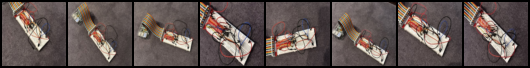

In [7]:
# ミニバッチを 1 つ取り出し，形（枚数・チャネル・高さ・幅）を確かめる
imgs, _ = next(iter(train_loader))
c, h, w = imgs[0].shape
print("ミニバッチサイズ:", len(imgs))
print("チャネル数:", c)
print("画像の高さ:", h)
print("画像の幅:", w)
print(imgs.shape)

# 取り出した画像を並べて表示する
img = torchvision.utils.make_grid(imgs)
img = transforms.functional.to_pil_image(img)
display(img)

### コードテンプレート⑦

カード名：R　カード：ネットワークの定義

In [8]:
# 入力画像のチャネル数・高さ・幅
INPUT_CHANNELS = c
IMAGE_HEIGHT = h
IMAGE_WIDTH = w

# 畳み込み層が出す特徴マップの枚数
CONV1_OUT_CHANNELS = 16

# 3×3 のフィルタで画像をなぞる．PADDING で縁を補い，POOL_SIZE で縦横を半分にする
KERNEL_SIZE = 3
PADDING = 1
POOL_SIZE = 2

POOL_NUM = 1

FC1_OUT_CHANNELS = 128

# 出力の数 = 分類するクラスの数
OUTPUT_SIZE = 2

# プーリング後の高さと幅（64 → 32）
OUT_HEIGHT = IMAGE_HEIGHT // (POOL_SIZE ** POOL_NUM)
OUT_WIDTH = IMAGE_WIDTH // (POOL_SIZE ** POOL_NUM)

# 全結合層に渡す長さ = 特徴マップの枚数 × 高さ × 幅
FLATTEN_SIZE = CONV1_OUT_CHANNELS * OUT_HEIGHT * OUT_WIDTH 

# 層を上から順に積み重ねてモデルを作る
model = nn.Sequential(
    # 畳み込み層：小さなフィルタで模様（特徴）を取り出す
    nn.Conv2d(INPUT_CHANNELS, CONV1_OUT_CHANNELS, kernel_size=KERNEL_SIZE, padding=PADDING),
    # 活性化関数：負の値を 0 にする
    nn.ReLU(),
    # プーリング：2×2 の中の最大値だけを残して縮小する
    nn.MaxPool2d(kernel_size=POOL_SIZE),
    # 画像（または特徴マップ）を 1 列のベクトルに伸ばす
    nn.Flatten(),
    # 全結合層：すべての入力とつながる
    nn.Linear(FLATTEN_SIZE, FC1_OUT_CHANNELS),
    nn.ReLU(),
    nn.Linear(FC1_OUT_CHANNELS, OUTPUT_SIZE)
)

# モデルを計算装置に載せる
model = model.to(device)

# 試しに 1 枚分のデータを通し，出力の形が (1, 2) になるかを確かめる
dummy_input = torch.randn(1, INPUT_CHANNELS, IMAGE_HEIGHT, IMAGE_WIDTH).to(device)
output = model(dummy_input)
print("ダミー入力の出力サイズ:", output.shape)
print("　↑　")
print("torch.Size([1,2]) になることを確認してください。")

model

ダミー入力の出力サイズ: torch.Size([1, 2])
　↑　
torch.Size([1,2]) になることを確認してください。


Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=16384, out_features=128, bias=True)
  (5): ReLU()
  (6): Linear(in_features=128, out_features=2, bias=True)
)

### コードテンプレート⑧

カード名：A　カード：損失関数の定義

In [9]:
# 損失関数：予測と正解のずれを測る（分類で標準の交差エントロピー）
criterion = nn.CrossEntropyLoss()

### コードテンプレート⑨

カード名：J　カード：最適化関数の定義

In [10]:
# 最適化手法：損失が小さくなる向きに重みを少しずつ動かす（学習率 0.001）
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 学習・評価フェーズ（⑩〜⑪）

### コードテンプレート⑩

カード名：E　カード：モデル学習&検証

In [11]:
EPOCHS = 20          # 授業では試行①②③とも 20 エポックにそろえる
# エポックごとの損失と正解率を記録するリスト
train_loss_list = []
val_loss_list = []
train_acc_list = []
val_acc_list = []

# 学習時間を測る（授業で追加）
import time
_t0 = time.perf_counter()
# EPOCHS 回，訓練データ全体を繰り返し学習する
for epoch in range(EPOCHS):
    # 訓練モードにする
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]', leave=False):
        images, labels = images.to(device), labels.to(device)

        # 前回の勾配を消す → 予測 → 損失を計算 → 誤差逆伝播で勾配を求める → 重みを更新
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        # 最も確率の高いクラスを予測とし，正解の数を数える
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_loss /= train_total
    train_accuracy = 100.0 * train_correct / train_total
    train_loss_list.append(train_loss)
    train_acc_list.append(train_accuracy)
    
    # 評価モードにする：ここからは検証データで確かめる（重みは更新しない）
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    # 勾配を計算しない（評価だけなので速く，メモリも少なくて済む）
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]', leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss /= val_total
    val_accuracy = 100.0 * val_correct / val_total
    val_loss_list.append(val_loss)
    val_acc_list.append(val_accuracy)

    # エポックごとの損失と正解率を表示する
    print(f'Epoch {epoch+1}/{EPOCHS},'
          f'Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}%,'
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%  ')

train_sec = time.perf_counter() - _t0
print(f'学習時間: {train_sec:.1f} 秒')

Epoch 1/20,Train Loss: 0.9388, Train Acc: 52.86%,Val Loss: 0.8521, Val Acc: 53.33%  


Epoch 2/20,Train Loss: 0.7524, Train Acc: 45.00%,Val Loss: 0.6698, Val Acc: 53.33%  


Epoch 3/20,Train Loss: 0.5898, Train Acc: 85.71%,Val Loss: 0.6281, Val Acc: 60.00%  


Epoch 4/20,Train Loss: 0.4769, Train Acc: 74.29%,Val Loss: 0.7979, Val Acc: 56.67%  


Epoch 5/20,Train Loss: 0.4622, Train Acc: 76.43%,Val Loss: 0.5750, Val Acc: 73.33%  


...

Epoch 16/20,Train Loss: 0.0276, Train Acc: 100.00%,Val Loss: 0.8649, Val Acc: 70.00%  


Epoch 17/20,Train Loss: 0.0217, Train Acc: 100.00%,Val Loss: 0.7157, Val Acc: 76.67%  


Epoch 18/20,Train Loss: 0.0176, Train Acc: 100.00%,Val Loss: 0.7566, Val Acc: 73.33%  


Epoch 19/20,Train Loss: 0.0170, Train Acc: 100.00%,Val Loss: 0.8628, Val Acc: 73.33%  


Epoch 20/20,Train Loss: 0.0173, Train Acc: 100.00%,Val Loss: 0.9136, Val Acc: 73.33%  
学習時間: 6.3 秒


### コードテンプレート⑪

カード名：K　カード：学習結果の可視化

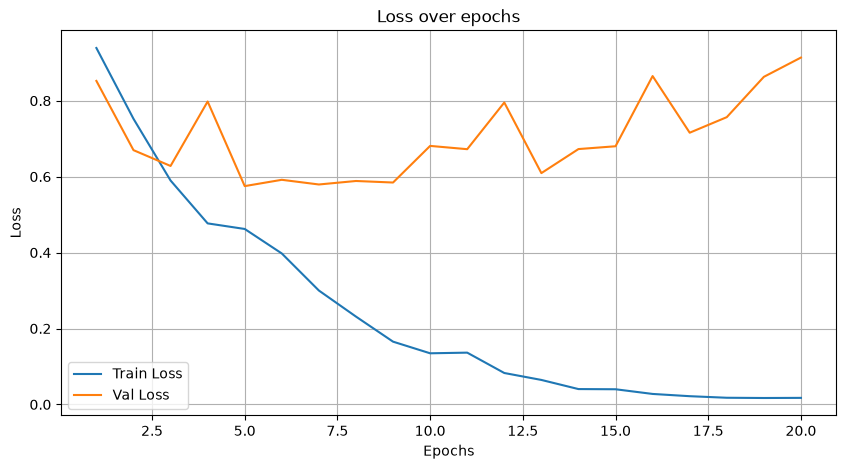

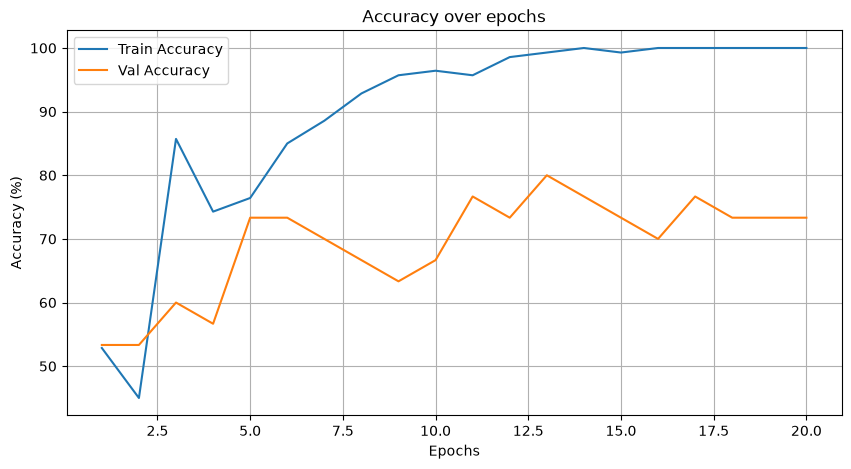

In [12]:
import seaborn as sns
# グラフを描く道具
import matplotlib.pyplot as plt
# 損失と正解率の推移をグラフにする（訓練と検証を比べる）
epochs = range(1, len(train_loss_list) + 1)
plt.figure(figsize=(10, 5))

sns.lineplot(x=epochs, y=train_loss_list, label='Train Loss')
sns.lineplot(x=epochs, y=val_loss_list, label='Val Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(x=epochs, y=train_acc_list, label='Train Accuracy')
sns.lineplot(x=epochs, y=val_acc_list, label='Val Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

## 記録

下のセルで結果を CSV に残す（試行①②③とも同じ CSV に行が増える）．討議の問いは授業ページ GW3 にある．


In [13]:
# 試行①②③のどれを実行したかを自動で判定して記録する（3 回とも同じ CSV に行が増える）
from common.logger import ResultLogger
data_name = "Cable1" if "IMAGE_DIR" in globals() else "FashionMNIST"
arch = "CNN" if any(isinstance(m, nn.Conv2d) for m in model.modules()) else "MLP"
metrics = {"epochs": EPOCHS, "train_sec": train_sec,
           "val_acc_best": max(val_acc_list) / 100, "val_acc_last": val_acc_list[-1] / 100}
if data_name == "FashionMNIST":
    metrics["test_accuracy"] = correct / total
logger = ResultLogger(GROUP_ID, MEMBER_ROLE, course="c1", day="d1", exercise="ex0", device=device)
logger.log_many(metrics, condition=f"{data_name}_{arch}", seed=0)
print("書き込み先:", logger.path)
print(f"{data_name} × {arch}  検証正解率 最高 {max(val_acc_list):.2f}% / 最終 {val_acc_list[-1]:.2f}%"
      f"  学習時間 {train_sec:.1f} 秒  エポック {EPOCHS}")

書き込み先: /Users/yamato/AI_TD/results/c1_d1_ex0_16.csv
Cable1 × CNN  検証正解率 最高 80.00% / 最終 73.33%  学習時間 6.3 秒  エポック 20


## 課題（提出）：MLP と CNN を説明する

このセルをダブルクリックして，＿＿ に書き込む（それぞれ 1〜2 文）．

1. **MLP とは何か**．画像をどんな形にしてから入力するか：

多層パーセプトロンのことであり、画像データを 1 列のベクトルに引き伸ばしてから入力する。


2. **CNN とは何か**．畳み込み層とプーリング層はそれぞれ何をするか：

畳み込み層でフィルタを用いて画像から局所的な特徴を抽出し、プーリング層でデータを縮小して重要な情報だけを残しつつ位置ズレへの頑健性を高める手法である。


3. 試行②と③の結果から，オリジナル画像で CNN が有利になりやすいのはなぜか：

MLP は画像を 1 次元化する際に画素の上下左右の位置関係を失うのに対し、CNN は 2 次元の形状を保ったまま特徴を捉えられるためである。
